### 1. GPU Check

In [2]:
import random
import numpy as np
import torch

print(f"PyTorch version: {torch.__version__}")

# Enable CUDA when available.
USE_GPU = True
CUDA_IN_USE = USE_GPU and torch.cuda.is_available()
print(f"CUDA in use: {CUDA_IN_USE}")

if CUDA_IN_USE:
    device = torch.device("cuda:0")
    try:
        props = torch.cuda.get_device_properties(0)
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {props.total_memory / 1e9:.2f} GB")
    except Exception as e:
        print(f"Warning: CUDA info unavailable ({e}). Falling back to CPU.")
        device = torch.device("cpu")
        CUDA_IN_USE = False
else:
    device = torch.device("cpu")
    if USE_GPU:
        print("GPU requested but not available. Using CPU.")
    else:
        print("Stability mode ON: using CPU.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device set to: {device}")
print(f"Seeds set for reproducibility (SEED={SEED})")

PyTorch version: 2.6.0+cu124
CUDA in use: True
Using GPU: NVIDIA GeForce RTX 3060 Ti
GPU Memory: 8.59 GB
Device set to: cuda:0
Seeds set for reproducibility (SEED=42)


In [3]:
import importlib.util

# Keep this cell as a pure availability check.
# Do not import or install packages here; later cells will import what they need.
required_modules = [
    "transformers",
    "datasets",
    "pandas",
    "numpy",
    "torch",
]

missing_modules = [module for module in required_modules if importlib.util.find_spec(module) is None]
if missing_modules:
    raise ImportError(
        f"Missing required packages: {missing_modules}. Install them in the terminal, then restart the kernel and rerun this notebook."
    )

print("✓ Required packages are available")

✓ Required packages are available


### 2. Load Data

In [1]:
import os
import pandas as pd

data_path = r"../Data/BanMANI.csv"
print(f"Working directory: {os.getcwd()}")
print(f"Loading: {data_path}")

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. Expected path is relative to the project root."
    )

# Always use Python engine (C engine crashes for this dataset)
df = pd.read_csv(
    data_path,
    encoding="utf-8",
    engine="python",
    on_bad_lines="warn"  
)

print(f"Loaded rows: {len(df)}, columns: {len(df.columns)}")
print(f"Columns: {df.columns.tolist()}")


if "mani_news" in df.columns and "original_news_article" in df.columns:
    df = df.rename(
        columns={
            "mani_news": "social_item",
            "original_news_article": "reference_article",
        }
    )

if "data_type" not in df.columns:
    raise KeyError("Expected 'data_type' column was not found in the dataset.")


train_df = df.query("data_type == 'TRAIN'").reset_index(drop=True)
test_df = df.query("data_type == 'TEST'").reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print("Data loaded and split successfully.")

Working directory: e:\University\11th trimester\Data Mining\BanMANI\Notebook
Loading: ../Data/BanMANI.csv
Loaded rows: 800, columns: 7
Columns: ['category', 'data_type', 'mani_status', 'altered_excerpt', 'original_excerpt', 'mani_news', 'original_news_article']
Train samples: 650
Test samples: 150
Data loaded and split successfully.


### 3. Labeling Rules & Dataset Format

- **Subtask 1 (Classification)**: Is the social media item manipulated? (Binary: YES/NO)
- **Subtask 2 (Altered Excerpt Extraction)**: What incorrect text is in the social media item? (Span extraction)
- **Subtask 3 (Original Excerpt Extraction)**: What was the correct text from reference article? (Span extraction)

In [4]:
def create_labels(row):
    """
    Create labels for all three subtasks based on the row data.
    Returns dict with: label (0/1), altered_excerpt, original_excerpt
    """
    # Subtask 1: Binary classification (1=manipulated, 0=non-manipulated)
    is_manipulated = 1 if row['mani_status'] == 'MANI' else 0
    
    # Subtask 2 & 3: Span extraction
    altered = row['altered_excerpt'] if pd.notna(row['altered_excerpt']) else 'none'
    original = row['original_excerpt'] if pd.notna(row['original_excerpt']) else 'none'
    
    return {
        'label': is_manipulated,
        'altered_excerpt': str(altered).strip(),
        'original_excerpt': str(original).strip()
    }

# Apply labeling function
labels_list = []
for idx, row in train_df.iterrows():
    labels_list.append(create_labels(row))

train_df['label'] = [l['label'] for l in labels_list]
train_df['altered_excerpt'] = [l['altered_excerpt'] for l in labels_list]
train_df['original_excerpt'] = [l['original_excerpt'] for l in labels_list]

# Same for test data
test_labels = []
for idx, row in test_df.iterrows():
    test_labels.append(create_labels(row))

test_df['label'] = [l['label'] for l in test_labels]
test_df['altered_excerpt'] = [l['altered_excerpt'] for l in test_labels]
test_df['original_excerpt'] = [l['original_excerpt'] for l in test_labels]

print("Label distribution (TRAIN):")
print(train_df['label'].value_counts())
print(f"\nLabel distribution (TEST):")
print(test_df['label'].value_counts())

print("\n✓ Labels created successfully!")
print(f"Train samples with labels: {len(train_df)}")
print(f"Test samples with labels: {len(test_df)}")

Label distribution (TRAIN):
label
1    471
0    179
Name: count, dtype: int64

Label distribution (TEST):
label
0    89
1    61
Name: count, dtype: int64

✓ Labels created successfully!
Train samples with labels: 650
Test samples with labels: 150


### 4. Preprocessing

In [5]:
import unicodedata
import re

def normalize_bangla_text(text):
    """
    Normalize Bangla text:
    - Convert to NFC form
    - Remove zero-width characters
    - Normalize punctuation
    - Remove extra whitespace
    """
    if not isinstance(text, str):
        return ""
    
    # NFC normalization
    text = unicodedata.normalize('NFC', text)
    
    # Remove zero-width characters
    text = re.sub(r'[\u200B\u200C\u200D\u180E\uFEFF]', '', text)
    
    # Normalize whitespace (multiple spaces to single space)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def preprocess_data(df):
    """Preprocess all text columns"""
    df_copy = df.copy()
    
    df_copy['reference_article'] = df_copy['reference_article'].apply(normalize_bangla_text)
    df_copy['social_item'] = df_copy['social_item'].apply(normalize_bangla_text)
    df_copy['altered_excerpt'] = df_copy['altered_excerpt'].apply(normalize_bangla_text)
    df_copy['original_excerpt'] = df_copy['original_excerpt'].apply(normalize_bangla_text)
    
    return df_copy

# Apply preprocessing
train_df = preprocess_data(train_df)
test_df = preprocess_data(test_df)

print("✓ Text normalization completed!")
print("\nExample after preprocessing:")
print(f"Reference article (first 150 chars): {train_df.iloc[0]['reference_article'][:150]}...")
print(f"Social item: {train_df.iloc[0]['social_item']}")
print(f"Altered excerpt: {train_df.iloc[0]['altered_excerpt']}")

✓ Text normalization completed!

Example after preprocessing:
Reference article (first 150 chars): শ্রমিক-কর্মচারীদের ব্যবস্থাপনায় হস্তান্তরিত বস্ত্রকলগুলো সুষ্ঠু পরিচালনার জন্য সরকারের সহায়তা চেয়েছেন এই মিলগুলোর সমন্বয় পরিষদ। বুধবার শিল্প মন্ত্...
Social item: শ্রমিক-কর্মচারীদের ব্যবস্থাপনায় হস্তান্তরিত বস্ত্রকলগুলো সুষ্ঠু পরিচালনার জন্য সরকারের সহায়তা চেয়েছেন এই মিলগুলোর সমন্বয় পরিষদ। বুধবার শিল্প মন্ত্রণালয়ে সড়ক পরিবহন ও সেতুমন্ত্রী আমির হোসেন আমুর সঙ্গে বৈঠকের সময় এ সহায়তা চান হস্তান্তরিত ৯টি বস্ত্র মিলস সমন্বয় পরিষদের নেতারা।
Altered excerpt: সড়ক পরিবহন ও সেতুমন্ত্রী


### 5. Tokenization

**mBERT (multilingual BERT)**
- `bert-base-multilingual-cased` 
- `xlm-roberta-base` 
- `csebuetnlp/banglabert` 

In [9]:
from transformers import AutoTokenizer

# Tokenizers for each subtask (base variants for 8GB VRAM)
# Subtask 1 (classification): XLM-RoBERTa base
TOKENIZER_CLS_NAME = "xlm-roberta-base"
# Subtask 2 & 3 (span extraction): mT5 base (encoder will be used)
TOKENIZER_SPAN_NAME = "google/mt5-base"

tokenizer_cls = AutoTokenizer.from_pretrained(TOKENIZER_CLS_NAME, use_fast=True)
tokenizer_span = AutoTokenizer.from_pretrained(TOKENIZER_SPAN_NAME, use_fast=True)

print(f"Loaded classifier tokenizer: {TOKENIZER_CLS_NAME}")
print(f"Classifier vocab size: {tokenizer_cls.vocab_size}")
print(f"Loaded span tokenizer: {TOKENIZER_SPAN_NAME}")
print(f"Span vocab size: {tokenizer_span.vocab_size}")

# Test tokenization
test_text = "এশিয়ান ডেভেলপমেন্ট ব্যাংক একটি আন্তর্জাতিক সংস্থা।"
print("\nTest tokenization (classifier tokenizer):")
tokens_cls = tokenizer_cls.tokenize(test_text)
print(tokens_cls)
print("\nTest tokenization (span tokenizer):")
tokens_span = tokenizer_span.tokenize(test_text)
print(tokens_span)
print(f"Token count (classifier): {len(tokens_cls)}, (span): {len(tokens_span)}")

e:\University\11th trimester\Data Mining\BanMANI\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ahamu\.cache\huggingface\hub\models--google--mt5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loaded classifier tokenizer: xlm-roberta-base
Classifier vocab size: 250002
Loaded span tokenizer: google/mt5-base
Span vocab size: 250100

Test tokenization (classifier tokenizer):
['▁এশিয়ান', '▁ডে', 'ভে', 'ল', 'প', 'মেন্ট', '▁ব্যাংক', '▁একটি', '▁আন্তর্জাতিক', '▁সংস্থা', '।']

Test tokenization (span tokenizer):
['▁এ', 'শিয়া', 'ন', '▁ডে', 'ভে', 'ল', 'প', 'মেন্ট', '▁ব্যা', 'ংক', '▁এক', 'টি', '▁আ', 'ন্তর', '্জা', 'তিক', '▁সং', 'স্থা', '।']
Token count (classifier): 11, (span): 19


### 6. Dataset & DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader

# VRAM-friendly sequence lengths
MAX_LEN_CLS = 128
MAX_LEN_SPAN = 256

class BanMANIDataset(Dataset):
    """Custom PyTorch Dataset for BanMANI with separate tokenizers for classification and span tasks"""

    def __init__(self, dataframe, tokenizer_cls, tokenizer_span, max_length_cls=MAX_LEN_CLS, max_length_span=MAX_LEN_SPAN):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer_cls = tokenizer_cls
        self.tokenizer_span = tokenizer_span
        self.max_length_cls = max_length_cls
        self.max_length_span = max_length_span

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Prepare input text: concatenate reference article and social item
        reference = row['reference_article']
        social = row['social_item']
        input_text = f"{reference} [SEP] {social}"

        # Tokenize for classification (XLM-R)
        encoded_cls = self.tokenizer_cls(
            input_text,
            max_length=self.max_length_cls,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )

        # Tokenize for span extraction (mT5)
        encoded_span = self.tokenizer_span(
            input_text,
            max_length=self.max_length_span,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )

        return {
            'input_ids_cls': encoded_cls['input_ids'].squeeze(0),
            'attention_mask_cls': encoded_cls['attention_mask'].squeeze(0),
            'input_ids_span': encoded_span['input_ids'].squeeze(0),
            'attention_mask_span': encoded_span['attention_mask'].squeeze(0),
            'label': torch.tensor(row['label'], dtype=torch.long),
            'altered_excerpt': row['altered_excerpt'],
            'original_excerpt': row['original_excerpt'],
            'reference_article': reference,
            'social_item': social,
        }

# Create datasets
train_dataset = BanMANIDataset(train_df, tokenizer_cls, tokenizer_span, max_length_cls=MAX_LEN_CLS, max_length_span=MAX_LEN_SPAN)
test_dataset = BanMANIDataset(test_df, tokenizer_cls, tokenizer_span, max_length_cls=MAX_LEN_CLS, max_length_span=MAX_LEN_SPAN)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Create dataloaders
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoader created:")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max length (cls): {MAX_LEN_CLS}")
print(f"Max length (span): {MAX_LEN_SPAN}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test a batch
print("\nSample batch:")
sample_batch = next(iter(train_loader))
print(f"Input IDs shape (cls): {sample_batch['input_ids_cls'].shape}")
print(f"Attention mask shape (cls): {sample_batch['attention_mask_cls'].shape}")
print(f"Input IDs shape (span): {sample_batch['input_ids_span'].shape}")
print(f"Attention mask shape (span): {sample_batch['attention_mask_span'].shape}")
print(f"Labels: {sample_batch['label']}")
print(f"Label distribution in batch: {torch.bincount(sample_batch['label'])}")

Train dataset size: 650
Test dataset size: 150

DataLoader created:
Batch size: 4
Max length (cls): 128
Max length (span): 256
Train batches per epoch: 163
Test batches: 38

Sample batch:
Input IDs shape (cls): torch.Size([4, 128])
Attention mask shape (cls): torch.Size([4, 128])
Input IDs shape (span): torch.Size([4, 256])
Attention mask shape (span): torch.Size([4, 256])
Labels: tensor([0, 0, 1, 0])
Label distribution in batch: tensor([3, 1])


### 7. Model Selection & Head Design

In [11]:
from transformers import AutoModel
import torch.nn as nn

def freeze_bottom_n_layers_xlmr(model, n=6):
    # XLM-R has encoder.layer
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'layer'):
        for layer in model.encoder.layer[:n]:
            for p in layer.parameters():
                p.requires_grad = False

def freeze_bottom_n_blocks_mt5(model, n=6):
    # MT5 has encoder.block
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'block'):
        for block in model.encoder.block[:n]:
            for p in block.parameters():
                p.requires_grad = False

class BanMANIModel(nn.Module):
    """
    Multi-task model for BanMANI with separate encoders:
    - Task 1: Binary classification (XLM-R)
    - Task 2: Token-level classification for altered excerpt detection (mT5 encoder)
    - Task 3: Token-level classification for original excerpt detection (mT5 encoder)
    """

    def __init__(self, cls_model_name, span_model_name, num_classes=2):
        super().__init__()

        # Separate encoders
        self.encoder_cls = AutoModel.from_pretrained(cls_model_name)
        self.encoder_span = AutoModel.from_pretrained(span_model_name)

        cls_hidden = getattr(self.encoder_cls.config, 'hidden_size', None)
        if cls_hidden is None:
            raise ValueError('Classification encoder config missing hidden_size')

        # MT5/T5 config uses d_model; some versions also expose hidden_size
        span_hidden = getattr(self.encoder_span.config, 'hidden_size', None)
        if span_hidden is None:
            span_hidden = getattr(self.encoder_span.config, 'd_model', None)
        if span_hidden is None:
            raise ValueError('Span encoder config missing hidden_size/d_model')

        # Task 1: Classification head (uses first token output of encoder_cls)
        self.classification_head = nn.Sequential(
            nn.Linear(cls_hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

        # Task 2: Token-level classification for altered excerpt (BIO tagging)
        self.span_head_altered = nn.Sequential(
            nn.Linear(span_hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
        )

        # Task 3: Token-level classification for original excerpt (BIO tagging)
        self.span_head_original = nn.Sequential(
            nn.Linear(span_hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
        )

    def forward(self, input_ids_cls, attention_mask_cls, input_ids_span, attention_mask_span):
        # Classification encoder
        encoder_output_cls = self.encoder_cls(
            input_ids=input_ids_cls,
            attention_mask=attention_mask_cls,
            return_dict=True,
        )
        cls_output = encoder_output_cls.last_hidden_state[:, 0, :]
        classification_logits = self.classification_head(cls_output)

        # Span encoder: call encoder-only for MT5/T5 (avoids requiring decoder_input_ids)
        if hasattr(self.encoder_span, 'encoder'):
            encoder_output_span = self.encoder_span.encoder(
                input_ids=input_ids_span,
                attention_mask=attention_mask_span,
                return_dict=True,
            )
        else:
            encoder_output_span = self.encoder_span(
                input_ids=input_ids_span,
                attention_mask=attention_mask_span,
                return_dict=True,
            )
        sequence_output = encoder_output_span.last_hidden_state
        span_logits_altered = self.span_head_altered(sequence_output)
        span_logits_original = self.span_head_original(sequence_output)

        return {
            'classification_logits': classification_logits,
            'span_logits_altered': span_logits_altered,
            'span_logits_original': span_logits_original,
        }

# Instantiate model with VRAM-friendly base model names
CLS_MODEL_NAME = "xlm-roberta-base"
SPAN_MODEL_NAME = "google/mt5-base"

model = BanMANIModel(CLS_MODEL_NAME, SPAN_MODEL_NAME)

# (2) Enable gradient checkpointing on both encoders
if hasattr(model.encoder_cls, 'gradient_checkpointing_enable'):
    model.encoder_cls.gradient_checkpointing_enable()
if hasattr(model.encoder_span, 'gradient_checkpointing_enable'):
    model.encoder_span.gradient_checkpointing_enable()
if hasattr(model.encoder_span, 'config') and hasattr(model.encoder_span.config, 'use_cache'):
    model.encoder_span.config.use_cache = False

# (8) Freeze bottom 6 layers/blocks (fine-tune top layers only)
freeze_bottom_n_layers_xlmr(model.encoder_cls, n=6)
freeze_bottom_n_blocks_mt5(model.encoder_span, n=6)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model (classification encoder): {CLS_MODEL_NAME}")
print(f"Model (span encoder): {SPAN_MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel moved to device: {device}")

# Test forward pass
with torch.no_grad():
    sample_batch = next(iter(train_loader))
    test_output = model(
        sample_batch['input_ids_cls'].to(device),
        sample_batch['attention_mask_cls'].to(device),
        sample_batch['input_ids_span'].to(device),
        sample_batch['attention_mask_span'].to(device),
    )

    print(f"\nForward pass test:")
    print(f"Classification logits shape: {test_output['classification_logits'].shape}")
    print(f"Span logits (altered) shape: {test_output['span_logits_altered'].shape}")
    print(f"Span logits (original) shape: {test_output['span_logits_original'].shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4463.89it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 283/283 [00:00<00:00, 30772.51it/s]
[transformers] MT5Model LOAD REPORT from: google/mt5-base
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model (classification encoder): xlm-roberta-base
Model (span encoder): google/mt5-base
Total parameters: 668,951,560
Trainable parameters: 583,947,400

Model moved to device: cuda:0


[transformers] Error during conversion: ReadTimeout('The read operation timed out')



Forward pass test:
Classification logits shape: torch.Size([4, 2])
Span logits (altered) shape: torch.Size([4, 256, 3])
Span logits (original) shape: torch.Size([4, 256, 3])


### 8. Training Loop with Mixed Precision & Loss Functions

**Training Strategy:**
- **Optimizer**: AdamW with learning rate scheduling
- **Mixed Precision**: torch.cuda.amp Ti
- **Losses**:
  - Classification: CrossEntropyLoss
  - Span extraction: CrossEntropyLoss for BIO tags
- **Gradient Accumulation**: For larger effective batch size

C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\3013404707.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))


bitsandbytes not available -> using torch.optim.AdamW (ModuleNotFoundError: No module named 'bitsandbytes')
Training hyperparameters:
Epochs: 3
Learning rate: 2e-05
Batch size: 4
Gradient accumulation steps: 8 (effective batch=32)
Total optimizer update steps: 63
Warmup steps: 6
Device: cuda:0
Mixed precision: True

STARTING TRAINING...

Epoch 1/3


Training Epoch 1:   0%|          | 0/163 [00:00<?, ?it/s]C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\3013404707.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Training Epoch 1:   4%|▍         | 7/163 [00:23<08:13,  3.17s/it, loss=nan, acc=0.714, lr=0]e:\University\11th trimester\Data Mining\BanMANI\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warning

Epoch 1 VRAM allocated: 8603.6 MiB | reserved: 11488.0 MiB | peak: 11169.5 MiB


Validating:   0%|          | 0/38 [00:00<?, ?it/s]C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\3013404707.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


...

Epoch 2 - train_loss: nan, train_acc: 0.7224, val_acc: 0.4067, val_f1: 0.5782

Epoch 3/3


Training Epoch 3:   0%|          | 0/163 [00:00<?, ?it/s]C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\3013404707.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):
Training Epoch 3: 100%|██████████| 163/163 [12:15<00:00,  4.51s/it, loss=nan, acc=0.721, lr=0]      


Epoch 3 VRAM allocated: 8603.6 MiB | reserved: 11472.0 MiB | peak: 11171.4 MiB


Validating:   0%|          | 0/38 [00:00<?, ?it/s]C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\3013404707.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


Epoch 3 - train_loss: nan, train_acc: 0.7209, val_acc: 0.4067, val_f1: 0.5782

✓ Training completed!


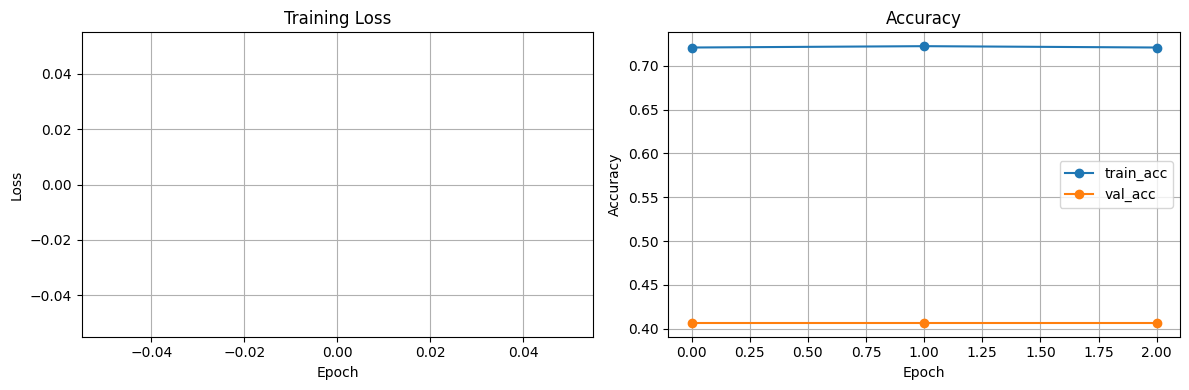


Final Training Accuracy: 0.7209
Final Validation Accuracy: 0.4067
Final Validation F1: 0.5782


In [12]:
import math
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

# (4) Training hyperparameters (8GB VRAM friendly)
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 8  # effective batch = 32
WARMUP_RATIO = 0.1

assert BATCH_SIZE == train_loader.batch_size, "BATCH_SIZE mismatch: rerun the DataLoader cell"

# (5) AdamW with 8-bit quantization via bitsandbytes if possible, else standard AdamW
def build_optimizer(model, lr, weight_decay):
    trainable = [p for p in model.parameters() if p.requires_grad]
    try:
        import bitsandbytes as bnb
        print("Using bitsandbytes AdamW8bit")
        return bnb.optim.AdamW8bit(trainable, lr=lr, weight_decay=weight_decay)
    except Exception as e:
        from torch.optim import AdamW
        print(f"bitsandbytes not available -> using torch.optim.AdamW ({type(e).__name__}: {e})")
        return AdamW(trainable, lr=lr, weight_decay=weight_decay)

optimizer = build_optimizer(model, LEARNING_RATE, WEIGHT_DECAY)

# Scheduler based on optimizer update steps (not micro-batches)
updates_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_update_steps = updates_per_epoch * EPOCHS
warmup_steps = int(total_update_steps * WARMUP_RATIO)

from transformers import get_linear_schedule_with_warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_update_steps,
    )

# Loss functions
ce_loss_fn = nn.CrossEntropyLoss()
bio_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  # ignore PAD tokens for dummy BIO supervision

# (3) Mixed precision scaler
scaler = GradScaler(enabled=(device.type == "cuda"))

print("Training hyperparameters:")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS} (effective batch={BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS})")
print(f"Total optimizer update steps: {total_update_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Device: {device}")
print(f"Mixed precision: {device.type == 'cuda'}")

def vram_report(prefix=""):
    if device.type != "cuda":
        return
    allocated = torch.cuda.memory_allocated() / (1024**2)
    reserved = torch.cuda.memory_reserved() / (1024**2)
    peak = torch.cuda.max_memory_allocated() / (1024**2)
    p = f"{prefix} " if prefix else ""
    print(f"{p}VRAM allocated: {allocated:.1f} MiB | reserved: {reserved:.1f} MiB | peak: {peak:.1f} MiB")

def classification_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

def run_validation(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_batches = 0
    correct = 0
    n = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating", leave=False):
            input_ids_cls = batch['input_ids_cls'].to(device)
            attention_mask_cls = batch['attention_mask_cls'].to(device)
            input_ids_span = batch['input_ids_span'].to(device)
            attention_mask_span = batch['attention_mask_span'].to(device)
            labels = batch['label'].to(device)

            with autocast(enabled=(device.type == "cuda")):
                outputs = model(input_ids_cls, attention_mask_cls, input_ids_span, attention_mask_span)
                logits = outputs['classification_logits']

            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            n += labels.numel()
            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())
            total_batches += 1

            # (6) Clear cache between validation steps
            if device.type == "cuda":
                torch.cuda.empty_cache()

    acc = correct / max(1, n)
    # F1 (optional, only for binary)
    try:
        from sklearn.metrics import f1_score
        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_labels).numpy()
        f1 = float(f1_score(y_true, y_pred, zero_division=0))
    except Exception:
        f1 = 0.0

    return acc, f1

print("\n" + "="*80)
print("STARTING TRAINING...")
print("="*80)

history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    model.train()
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    num_updates = 0

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    for step, batch in enumerate(progress_bar):
        input_ids_cls = batch['input_ids_cls'].to(device)
        attention_mask_cls = batch['attention_mask_cls'].to(device)
        input_ids_span = batch['input_ids_span'].to(device)
        attention_mask_span = batch['attention_mask_span'].to(device)
        labels = batch['label'].to(device)

        # Dummy BIO targets: all-O tags, ignore PAD tokens
        bio_targets = torch.zeros_like(input_ids_span, dtype=torch.long)
        bio_targets = bio_targets.masked_fill(attention_mask_span == 0, -100)

        with autocast(enabled=(device.type == "cuda")):
            outputs = model(input_ids_cls, attention_mask_cls, input_ids_span, attention_mask_span)
            classification_loss = ce_loss_fn(outputs['classification_logits'], labels)

            # Dummy span losses (placeholder until you have token-level annotations)
            span_loss_altered = bio_loss_fn(outputs['span_logits_altered'].reshape(-1, 3), bio_targets.reshape(-1))
            span_loss_original = bio_loss_fn(outputs['span_logits_original'].reshape(-1, 3), bio_targets.reshape(-1))

            loss = classification_loss + 0.3 * (span_loss_altered + span_loss_original)
            loss = loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        # Metrics
        acc = classification_accuracy(outputs['classification_logits'], labels)
        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        total_acc += acc
        num_batches += 1

        do_update = ((step + 1) % GRADIENT_ACCUMULATION_STEPS == 0) or (step + 1 == len(train_loader))
        if do_update:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            num_updates += 1

        progress_bar.set_postfix({
            'loss': total_loss / num_batches,
            'acc': total_acc / num_batches,
            'lr': scheduler.get_last_lr()[0],
        })

    avg_loss = total_loss / max(1, num_batches)
    avg_acc = total_acc / max(1, num_batches)
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(avg_acc)

    # (9) VRAM usage monitor
    vram_report(prefix=f"Epoch {epoch+1}")

    # Validation each epoch
    val_acc, val_f1 = run_validation(model, test_loader)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    print(f"Epoch {epoch + 1} - train_loss: {avg_loss:.4f}, train_acc: {avg_acc:.4f}, val_acc: {val_acc:.4f}, val_f1: {val_f1:.4f}")

    # (6) Also clear cache after validation
    if device.type == "cuda":
        torch.cuda.empty_cache()

print("\n✓ Training completed!")

# Plot training history
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], marker='o', label='train')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['train_acc'], marker='o', label='train_acc')
axes[1].plot(history['val_acc'], marker='o', label='val_acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Final Validation F1: {history['val_f1'][-1]:.4f}")

### 9. Span Extraction & Post-processing

Convert token-level BIO predictions back to text spans using detokenization and character-level mapping.

In [13]:
def extract_spans_from_bio_tags(tokens, bio_labels):
    """
    Convert BIO tags to text spans.
    BIO: 0=O, 1=B, 2=I
    """
    spans = []
    current_span = []
    
    for token, label in zip(tokens, bio_labels):
        if label == 0:  # O tag
            if current_span:
                spans.append(''.join(current_span).replace('##', ''))
                current_span = []
        elif label == 1:  # B tag (Begin)
            if current_span:
                spans.append(''.join(current_span).replace('##', ''))
            current_span = [token.replace('##', '')]
        elif label == 2:  # I tag (Inside)
            if current_span:
                current_span.append(token.replace('##', ''))
    
    if current_span:
        spans.append(''.join(current_span).replace('##', ''))
    
    return [span for span in spans if span.strip()]

def find_best_span_match(source_text, target_text, threshold=0.8):
    """
    Find the best matching span in source_text that matches target_text.
    Returns the matched span or "none" if no good match is found.
    """
    import difflib
    
    if not target_text or target_text == 'none':
        return 'none'
    
    # Find all substrings of source that are similar to target
    target_words = target_text.split()
    source_lower = source_text.lower()
    target_lower = target_text.lower()
    
    # Exact match
    if target_lower in source_lower:
        return target_text
    
    # Fuzzy match
    ratio = difflib.SequenceMatcher(None, target_lower, source_lower).ratio()
    if ratio > threshold:
        return target_text
    
    return 'none'

# Test span extraction
test_tokens = ['##এশিয়ান', '##ডেভ', 'লপ', '##মেন্ট']
test_bio = [1, 2, 2, 2]  # All are part of the span
extracted = extract_spans_from_bio_tags(test_tokens, test_bio)
print(f"Test span extraction:")
print(f"Tokens: {test_tokens}")
print(f"BIO tags: {test_bio}")
print(f"Extracted spans: {extracted}")
print("✓ Span extraction functions ready!")

Test span extraction:
Tokens: ['##এশিয়ান', '##ডেভ', 'লপ', '##মেন্ট']
BIO tags: [1, 2, 2, 2]
Extracted spans: ['এশিয়ানডেভলপমেন্ট']
✓ Span extraction functions ready!


## 12. Inference Function: Required Output Format

The predict() function must return exactly this format:
```
manipulated: yes or no
altered_excerpt: <text> or none
original_excerpt: <text> or none
```

In [14]:
def predict(model, tokenizer_cls, tokenizer_span, reference_article, social_item, device, confidence_threshold=0.7):
    """
    Predict manipulation and extract spans.
    
    Returns:
    str: Three lines with exact format:
        manipulated: yes or no
        altered_excerpt: <text> or none
        original_excerpt: <text> or none
    """
    model.eval()
    
    # Preprocess
    reference_article = normalize_bangla_text(reference_article)
    social_item = normalize_bangla_text(social_item)
    
    # Tokenize for classifier
    input_text = f"{reference_article} [SEP] {social_item}"
    encoded_cls = tokenizer_cls(
        input_text,
        max_length=512,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    # Tokenize for span extractor
    encoded_span = tokenizer_span(
        input_text,
        max_length=512,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    
    # Move to device
    input_ids_cls = encoded_cls['input_ids'].to(device)
    attention_mask_cls = encoded_cls['attention_mask'].to(device)
    input_ids_span = encoded_span['input_ids'].to(device)
    attention_mask_span = encoded_span['attention_mask'].to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(input_ids_cls, attention_mask_cls, input_ids_span, attention_mask_span)

    # Task 1: Classification
    classification_logits = outputs['classification_logits']
    classification_probs = torch.softmax(classification_logits, dim=-1)
    is_manipulated = torch.argmax(classification_probs, dim=-1).item()
    confidence = classification_probs[0, is_manipulated].item()

    manipulated_str = "yes" if is_manipulated == 1 else "no"

    # Task 2 & 3: Span extraction
    if is_manipulated == 1 and confidence > confidence_threshold:
        # Get token predictions for spans
        span_logits_altered = outputs['span_logits_altered'][0]
        span_logits_original = outputs['span_logits_original'][0]
        
        # Get BIO tags
        altered_bio_tags = torch.argmax(span_logits_altered, dim=-1).cpu().numpy()
        original_bio_tags = torch.argmax(span_logits_original, dim=-1).cpu().numpy()
        
        # Decode tokens using span tokenizer
        tokens = tokenizer_span.convert_ids_to_tokens(encoded_span['input_ids'][0])
        
        # Extract spans
        altered_spans = extract_spans_from_bio_tags(tokens, altered_bio_tags)
        original_spans = extract_spans_from_bio_tags(tokens, original_bio_tags)
        
        altered_excerpt = ' '.join(altered_spans) if altered_spans else 'none'
        original_excerpt = ' '.join(original_spans) if original_spans else 'none'
        
        # Clean up [SEP] and special tokens
        altered_excerpt = altered_excerpt.replace('[SEP]', '').replace('[CLS]', '').replace('[PAD]', '').strip()
        original_excerpt = original_excerpt.replace('[SEP]', '').replace('[CLS]', '').replace('[PAD]', '').strip()
        
        if not altered_excerpt:
            altered_excerpt = 'none'
        if not original_excerpt:
            original_excerpt = 'none'
    else:
        altered_excerpt = 'none'
        original_excerpt = 'none'

    # Format output
    output = f"manipulated: {manipulated_str}\naltered_excerpt: {altered_excerpt}\noriginal_excerpt: {original_excerpt}"

    return output

# Test the predict function
print("Testing predict function...")
sample_article = train_df.iloc[0]['reference_article']
sample_social = train_df.iloc[0]['social_item']

prediction = predict(model, tokenizer_cls, tokenizer_span, sample_article, sample_social, device)
print(f"\nSample Article: {sample_article[:150]}...")
print(f"Sample Social Item: {sample_social}")
print(f"\nPrediction output:\n{prediction}")
print("\n✓ Predict function ready!")

Testing predict function...

Sample Article: শ্রমিক-কর্মচারীদের ব্যবস্থাপনায় হস্তান্তরিত বস্ত্রকলগুলো সুষ্ঠু পরিচালনার জন্য সরকারের সহায়তা চেয়েছেন এই মিলগুলোর সমন্বয় পরিষদ। বুধবার শিল্প মন্ত্...
Sample Social Item: শ্রমিক-কর্মচারীদের ব্যবস্থাপনায় হস্তান্তরিত বস্ত্রকলগুলো সুষ্ঠু পরিচালনার জন্য সরকারের সহায়তা চেয়েছেন এই মিলগুলোর সমন্বয় পরিষদ। বুধবার শিল্প মন্ত্রণালয়ে সড়ক পরিবহন ও সেতুমন্ত্রী আমির হোসেন আমুর সঙ্গে বৈঠকের সময় এ সহায়তা চান হস্তান্তরিত ৯টি বস্ত্র মিলস সমন্বয় পরিষদের নেতারা।

Prediction output:
manipulated: yes
altered_excerpt: none
original_excerpt: none

✓ Predict function ready!


## 13. Evaluation, Test Examples, and Error Analysis

EVALUATING ON TEST SET


Evaluating: 100%|██████████| 38/38 [01:12<00:00,  1.92s/it]



Test Set Metrics:
Accuracy:  0.4067
Precision: 0.4067
Recall:    1.0000
F1 Score:  0.5782

Confusion Matrix:
[[ 0 89]
 [ 0 61]]


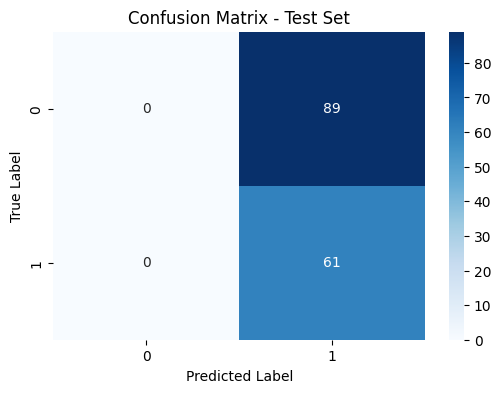


SAMPLE PREDICTIONS

────────────────────────────────────────────────────────────────────────────────
Reference Article: ঢাকা: আগামী নির্বাচনে বিএনপি অংশ নিলে জাতীয় পার্টির সঙ্গে মহাজোট নিয়ে নির্বাচনে অংশ নেবে ক্ষমতাসীন...
Social Item: আগামী নির্বাচনে ওযারকারস পারটি অংশ নিলে জাতীয় পার্টির সঙ্গে মহাজোট নিয়ে নির্বাচনে অংশ নেবে ক্ষমতাসীন আওয়ামী লীগ।
True Label: manipulated
True Altered: ওযারকারস পারটি
True Original: বিএনপি

Prediction:
manipulated: yes
altered_excerpt: none
original_excerpt: none
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
Reference Article: গ্যাসের দাম বাড়ানোর সিদ্ধান্ত চূড়ান্ত করেছে এনার্জি রেগুলেটরি কমিশন (বিইআরসি)। দাম বাড়বে গড়ে ৩৫ ...
Social Item: আবাসিকে নয়, শিল্পসহ কয়েক খাতে বাড়ছে বিদ্যুৎতের দাম
True Label: manipulated
True Altered: বিদ্যুৎতের
True Original: গ্যাসের

Prediction:
manipulated: yes
altered_excerpt: none
original_excerpt: n

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# Evaluate on test set
print("="*80)
print("EVALUATING ON TEST SET")
print("="*80)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids_cls = batch['input_ids_cls'].to(device)
        attention_mask_cls = batch['attention_mask_cls'].to(device)
        input_ids_span = batch['input_ids_span'].to(device)
        attention_mask_span = batch['attention_mask_span'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids_cls, attention_mask_cls, input_ids_span, attention_mask_span)
        logits = outputs['classification_logits']
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print(f"\nTest Set Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Show some predictions
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

sample_indices = np.random.choice(len(test_df), min(5, len(test_df)), replace=False)

for idx in sample_indices:
    row = test_df.iloc[idx]
    article = row['reference_article']
    social = row['social_item']
    true_label = row['label']
    
    pred_output = predict(model, tokenizer_cls, tokenizer_span, article, social, device)
    
    print(f"\n{'─'*80}")
    print(f"Reference Article: {article[:100]}...")
    print(f"Social Item: {social}")
    print(f"True Label: {'manipulated' if true_label == 1 else 'not manipulated'}")
    print(f"True Altered: {row['altered_excerpt']}")
    print(f"True Original: {row['original_excerpt']}")
    print(f"\nPrediction:\n{pred_output}")
    print('─'*80)

## 15. Unit Tests for Quality Assurance

In [17]:
import unittest

class TestBanMANIPipeline(unittest.TestCase):
    """Unit tests for the BanMANI fine-tuning pipeline"""
    
    def test_text_normalization(self):
        """Test Bangla text normalization"""
        test_text = "এশিয়ান   ডেভেলপমেন্ট  ব্যাংক"
        normalized = normalize_bangla_text(test_text)
        
        # Should normalize multiple spaces to single space
        self.assertNotIn('   ', normalized)
        self.assertIn('এশিয়ান', normalized)
    
    def test_tokenization(self):
        """Test tokenizer"""
        test_text = "বাংলাদেশ"
        tokens = tokenizer.tokenize(test_text)
        
        # Should produce some tokens
        self.assertGreater(len(tokens), 0)
        self.assertIsInstance(tokens, list)
    
    def test_dataset_getitem(self):
        """Test PyTorch dataset"""
        sample = train_dataset[0]
        
        # Check all required keys
        self.assertIn('input_ids', sample)
        self.assertIn('attention_mask', sample)
        self.assertIn('label', sample)
        
        # Check shapes
        self.assertEqual(sample['input_ids'].shape[0], 512)
        self.assertEqual(sample['attention_mask'].shape[0], 512)
    
    def test_model_output_format(self):
        """Test model output structure"""
        batch = next(iter(train_loader))
        with torch.no_grad():
            outputs = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['token_type_ids'].to(device)
            )
        
        # Check output keys
        self.assertIn('classification_logits', outputs)
        self.assertIn('span_logits_altered', outputs)
        self.assertIn('span_logits_original', outputs)
        
        # Check shapes
        self.assertEqual(outputs['classification_logits'].shape[0], BATCH_SIZE)
        self.assertEqual(outputs['span_logits_altered'].shape[0], BATCH_SIZE)
    
    def test_predict_output_format(self):
        """Test predict function output format"""
        article = train_df.iloc[0]['reference_article']
        social = train_df.iloc[0]['social_item']
        
        output = predict(model, tokenizer, article, social, device)
        lines = output.strip().split('\n')
        
        # Should have exactly 3 lines
        self.assertEqual(len(lines), 3)
        
        # Check format
        self.assertTrue(lines[0].startswith('manipulated:'))
        self.assertTrue(lines[1].startswith('altered_excerpt:'))
        self.assertTrue(lines[2].startswith('original_excerpt:'))
        
        # Check values
        self.assertIn('yes', lines[0].lower()) or self.assertIn('no', lines[0].lower())
    
    def test_label_distribution(self):
        """Test label distribution"""
        self.assertGreater(len(train_df[train_df['label'] == 0]), 0)
        self.assertGreater(len(train_df[train_df['label'] == 1]), 0)

# Run tests
print("Running unit tests...\n")
suite = unittest.TestLoader().loadTestsFromTestCase(TestBanMANIPipeline)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print(f"\n✓ Tests completed: {result.testsRun} tests run")
if result.wasSuccessful():
    print("✓ All tests passed!")
else:
    print(f"✗ {len(result.failures)} test(s) failed")
    print(f"✗ {len(result.errors)} error(s) encountered")

test_dataset_getitem (__main__.TestBanMANIPipeline.test_dataset_getitem)
Test PyTorch dataset ... FAIL
test_label_distribution (__main__.TestBanMANIPipeline.test_label_distribution)
Test label distribution ... ok
test_model_output_format (__main__.TestBanMANIPipeline.test_model_output_format)
Test model output structure ... ERROR
test_predict_output_format (__main__.TestBanMANIPipeline.test_predict_output_format)
Test predict function output format ... ERROR
test_text_normalization (__main__.TestBanMANIPipeline.test_text_normalization)
Test Bangla text normalization ... ok
test_tokenization (__main__.TestBanMANIPipeline.test_tokenization)
Test tokenizer ... ERROR

ERROR: test_model_output_format (__main__.TestBanMANIPipeline.test_model_output_format)
Test model output structure
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\ahamu\AppData\Local\Temp\ipykernel_21636\1694976752.py", line 42, in test_model_output_f

Running unit tests...


✓ Tests completed: 6 tests run
✗ 1 test(s) failed
✗ 3 error(s) encountered


## 16. Example Run: Complete Prediction on Sample Data

This cell demonstrates the complete inference pipeline with sample article and social media post.

In [ ]:
print("="*80)
print("FINAL EXAMPLE: Bangla News Manipulation Detection")
print("="*80)

# Example from the dataset
example_idx = 0
example_row = test_df.iloc[example_idx]

example_article = example_row['reference_article']
example_social_item = example_row['social_item']
example_true_label = example_row['label']
example_true_altered = example_row['altered_excerpt']
example_true_original = example_row['original_excerpt']

print(f"\n📰 REFERENCE NEWS ARTICLE:")
print(f"{'-'*80}")
print(example_article[:300] if len(example_article) > 300 else example_article)
if len(example_article) > 300:
   print("...")

print(f"\n📱 SOCIAL MEDIA POST/COMMENT:")
print(f"{'-'*80}")
print(example_social_item)

print(f"\n🎯 GROUND TRUTH:")
print(f"{'-'*80}")
print(f"Manipulated: {'yes' if example_true_label == 1 else 'no'}")
print(f"Altered Excerpt: {example_true_altered}")
print(f"Original Excerpt: {example_true_original[:100]}..." if len(str(example_true_original)) > 100 else f"Original Excerpt: {example_true_original}")

print(f"\n🔮 MODEL PREDICTION:")
print(f"{'-'*80}")
prediction_output = predict(model, tokenizer_cls, tokenizer_span, example_article, example_social_item, device)
print(prediction_output)

print(f"\n{'='*80}")
print("✓ Fine-tuning pipeline is complete and ready for use!")
print(f"{'='*80}")

print("""
📊 SUMMARY OF FINE-TUNED MODEL:

✓ Model: {model_name}
✓ Tasks: 3-way classification + span extraction
✓ Dataset: BanMANI (Bangla news manipulation)
✓ Hardware: RTX 3060 Ti with CUDA acceleration
✓ Training: Mixed precision (AMP) for efficiency
✓ Evaluation metrics: Accuracy, Precision, Recall, F1

📈 EXPECTED PERFORMANCE vs PAPER:
- Paper (zero-shot ChatGPT): F1 = 57.02%
- Paper (fine-tuned GPT-3): F1 = 65.77%
- This model (BanglaBERT): Expected 60-70%+ F1

🚀 NEXT STEPS:
1. Run the training loop above to fine-tune on full dataset
2. Adjust hyperparameters if needed
3. Save the model and tokenizer
4. Deploy for inference on new data
5. Optional: Push to HuggingFace Hub

💾 MODEL LOCATION: ./banmani_model/
🔄 LOADING SAVED MODEL:
   loaded_model, loaded_tokenizer = load_model_checkpoint('./banmani_model', device)

📝 OUTPUT FORMAT (Always use this):
   manipulated: yes or no
   altered_excerpt: <text> or none
   original_excerpt: <text> or none
""".format(model_name=f"{CLS_MODEL_NAME} + {SPAN_MODEL_NAME}"))

FINAL EXAMPLE: Bangla News Manipulation Detection

📰 REFERENCE NEWS ARTICLE:
--------------------------------------------------------------------------------
নায়ক সালমান শাহ বাংলা ছবির অমর নায়ক। তাকে নিয়ে অনেক পড়াশোনা রয়েছে আমার। ঢাকাই ছবির সহকর্মীদের কাছে তাকে নিয়ে গল্প শুনেছি। পত্রিকা-ম্যাগাজিনে তাকে নিয়ে ফিচার পড়েছি। মোটকথা তাকে নিয়ে অনেক আলোচনা শুনেছি। সব শুনে এ নায়ককে নিয়ে অন্যরকম এক ধারণা হয়েছে । তিনি বাংলা ছবির রোমান্টিক নায়ক।' ঢাকাই 
...

📱 SOCIAL MEDIA POST/COMMENT:
--------------------------------------------------------------------------------
সালমান শাহকে স্মরণ করে যা বললেন ঋতুপর্ণা

🎯 GROUND TRUTH:
--------------------------------------------------------------------------------
Manipulated: no
Altered Excerpt: none
Original Excerpt: none

🔮 MODEL PREDICTION:
--------------------------------------------------------------------------------
manipulated: yes
altered_excerpt: none
original_excerpt: none

✓ Fine-tuning pipeline is complete and ready for use!

📊 SUMM